# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Akshay Prakash (2503690F)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [30]:
## Import libraries
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Preprocessing and splitting (scikit-learn only, per project specification)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

## Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# 1. Business Understanding

**Objective:** predict the presence of heart disease from 11 routinely-collected clinical measurements (age, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG, max heart rate achieved, exercise-induced angina, ST depression/slope), enabling a clinician to escalate a patient toward cardiology review *before* the condition reaches a critical stage.

**Problem framing:** binary classification. Target `HeartDisease` — `1` indicates disease present, `0` indicates no disease.

The two ways this model can be wrong carry very different consequences:

| Outcome | **What it looks like in practice** | **Who bears the consequence** |
| --- | --- | --- |
| **Missed case** (false negative) | a patient who actually has heart disease is cleared and sent home with no referral | the patient, whose disease progresses silently toward a potential heart attack, stroke, or sudden cardiac death — and, further downstream, the health system, which absorbs the far higher cost of emergency cardiac care versus the cost of early intervention it skipped |
| **False alarm** (false positive) | a healthy patient is flagged and sent for additional cardiac workup (e.g. stress test, angiogram) | the patient, who incurs added expense, anxiety, and the small but real procedural risk of an invasive test they didn't need |

Because these two outcomes are priced so differently, the class split is beside the point — even a perfectly balanced dataset would still make accuracy the wrong number to optimize for, since it treats both mistakes as equally bad when they clearly aren't.

This model is intended to sit in a primary-care setting as a triage aid — a second opinion a GP consults during a routine visit — rather than as a cardiologist's final diagnostic tool or a consumer-facing app used without clinical oversight. Under that framing, a missed case is the more expensive mistake in three distinct ways: clinically, because untreated disease progresses toward an acute event — heart attack, stroke, or sudden cardiac death — with worse outcomes and fewer treatment options the longer it goes undetected; financially, because the eventual cost of emergency treatment, hospitalization, or long-term cardiac damage management dwarfs what an earlier referral and preventive treatment would have cost, a pattern well documented in health-economics literature on delayed cardiac diagnosis; and in the worst case, irreversibly, since a missed diagnosis can end in permanent disability or death rather than a cost that's merely expensive to fix. A false alarm is not free, either: it costs the patient money, stress, and exposure to procedural risk from a test they didn't need, and it consumes limited specialist capacity that a true case could have used instead — but it is recoverable in a way a missed fatal event is not. Given this, the model should be tuned to favor recall over precision, but deliberately, with a stated threshold or cost ratio in section 5 — not by default, and not so far in that precision collapses and false alarms start eating away at the very capacity we're trying to protect.

**Working assumptions**

1. The 11 input features are obtainable through a standard clinical workup — history, resting ECG, and a fasting blood panel (cholesterol, fasting blood sugar). Note this is *not* all available in a single instant office visit: cholesterol and fasting blood sugar require prior fasting and lab turnaround, so in practice the full feature set is assembled over one or two visits rather than in real time during triage.
2. The model's output supports a referral decision; it does not stand in for clinical judgment or constitute a diagnosis.
3. The training population is assumed to reasonably reflect the deployment population. This is worth treating skeptically rather than as a formality — this dataset is a merge of five separate cohorts collected across different countries and time periods, so distributional mismatch is a live risk to revisit in the EDA/limitations discussion.
4. The physiological relationships between these clinical markers and heart disease are not expected to drift quickly over time — so a recall/precision tradeoff chosen now should stay reasonably valid without frequent retraining.

# 2. Data Understanding

## 2.1 Load dataset

In [31]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("dataset.csv")

## Keep an untouched copy so that cleaning in section 3 can be compared against the raw data
df_raw = df.copy()

print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

df.head()

Rows: 918  Columns: 12
Duplicate rows: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The dataset loads with 918 patient records and 12 columns: 11 predictors and the `HeartDisease` target. This clears the 200-sample minimum, but it is small enough that the train-test split in section 3.2 must be stratified, otherwise the test set may not preserve the class ratio and the reported metrics will be unstable.

Source: Fedesoriano, *Heart Failure Prediction Dataset* (Kaggle). This file is a merge of five separate cardiology cohorts — Cleveland, Hungarian, Switzerland, Long Beach VA and Stalog — with 272 duplicate records already removed by the compiler, which is why `duplicated()` returns zero here. That merge is not a background detail: it is the origin of the data quality problem uncovered in 2.2 and the main threat to how this model generalises.

## 2.2 Summary Statistics

In [32]:
## Understand the type of variable for each column
df.info()

## Group columns by how they will need to be handled later.
## FastingBS is stored as a number but is really a 0/1 flag, so it is grouped with
## the categorical columns and will not be scaled like a continuous measurement.
target = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
category_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]

## Print the levels of each categorical column to catch typos or unexpected values
print("\nCategorical levels:")
for col in category_cols:
    print(col, "->", sorted(df[col].unique().tolist(), key=str))

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB

Categorical levels:
Sex -> ['F', 'M']
ChestPainType -> ['ASY', 'ATA', 'NAP', 'TA']
RestingECG -> ['LVH', 'Normal', 'ST']
ExerciseAngina -> ['N', 'Y']
ST_Slope -> ['Down', 'Flat', 'Up']
FastingBS -> [0, 1]


In [33]:
## Check for missing data

## Count explicit missing values
print("Explicit missing values per column:")
print(df.isna().sum())

## A value of 0 is biologically impossible for these measurements, so a 0 recorded
## here is really a missing value in disguise. isna() will not find these.
print("\nZeros in columns where 0 is impossible:")
for col in ["RestingBP", "Cholesterol", "MaxHR"]:
    n = (df[col] == 0).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## Check whether the disguised missing values are spread evenly across the target.
## If they are not, "this test was never run" is itself a clue about the diagnosis,
## which is a leakage risk rather than a clinical signal.
print("\nDisease rate by whether cholesterol was recorded:")
print(df.groupby(df["Cholesterol"] == 0)[target].mean().round(3))
print("\nRow counts:")
print(df.groupby(df["Cholesterol"] == 0)[target].size())

Explicit missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zeros in columns where 0 is impossible:
RestingBP : 1 rows ( 0.1 % )
Cholesterol : 172 rows ( 18.7 % )
MaxHR : 0 rows ( 0.0 % )

Disease rate by whether cholesterol was recorded:
Cholesterol
False    0.477
True     0.884
Name: HeartDisease, dtype: float64

Row counts:
Cholesterol
False    746
True     172
Name: HeartDisease, dtype: int64


In [34]:
## Describe data distribution

## Spread and central tendency of the continuous columns
print("Continuous features:")
display(df[numeric_cols].describe().round(2))

## Skew tells us whether a distribution is lopsided enough to need a transform
print("Skewness (values beyond +/-1 are heavily one-sided):")
print(df[numeric_cols].skew().round(2))

## Proportions rather than raw counts, so rare categories are easy to spot
print("\nCategory proportions (%):")
for col in category_cols:
    print("\n" + col)
    print((df[col].value_counts(normalize=True) * 100).round(1))

Continuous features:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,136.81,0.89
std,9.43,18.51,109.38,25.46,1.07
min,28.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,120.00,0.00
50%,54.00,130.00,223.00,138.00,0.60
75%,60.00,140.00,267.00,156.00,1.50
max,77.00,200.00,603.00,202.00,6.20


Skewness (values beyond +/-1 are heavily one-sided):
Age           -0.20
RestingBP      0.18
Cholesterol   -0.61
MaxHR         -0.14
Oldpeak        1.02
dtype: float64

Category proportions (%):

Sex
Sex
M    79.0
F    21.0
Name: proportion, dtype: float64

ChestPainType
ChestPainType
ASY    54.0
NAP    22.1
ATA    18.8
TA      5.0
Name: proportion, dtype: float64

RestingECG
RestingECG
Normal    60.1
LVH       20.5
ST        19.4
Name: proportion, dtype: float64

ExerciseAngina
ExerciseAngina
N    59.6
Y    40.4
Name: proportion, dtype: float64

ST_Slope
ST_Slope
Flat    50.1
Up      43.0
Down     6.9
Name: proportion, dtype: float64

FastingBS
FastingBS
0    76.7
1    23.3
Name: proportion, dtype: float64


### 2.2.1 What the summary statistics reveal

**`isna()` reports zero missing values, and that is misleading.** Two columns contain values that cannot occur in a living patient:

| Column | Impossible value | Count | Share | What it actually means |
| --- | --- | --- | --- | --- |
| `Cholesterol` | 0 mg/dl | 172 | 18.7% | no lipid panel was ever drawn |
| `RestingBP` | 0 mm Hg | 1 | 0.1% | a data-entry error |

No living patient has a serum cholesterol of zero. These are missing values wearing a numeric disguise. Left untouched they pull the reported mean cholesterol down to 198.8 mg/dl, roughly 46 mg/dl below the true mean of the measured patients, and teach the model that "extremely low cholesterol" is a real clinical state when it is really an absent lab result. The same artefact is what makes `Cholesterol` skew negative (−0.61) despite serum cholesterol being a naturally right-tailed measurement.

**The missingness is not random, and this is the most important finding in the whole EDA.** Grouping the target by whether cholesterol was recorded is stark: patients with a recorded value are disease-positive 47.7% of the time, while patients whose cholesterol reads 0 are disease-positive **88.4%** of the time. The cause is structural, not clinical — the merged cohorts did not all collect lipid panels, and the sub-cohort that skipped them also happens to have far higher disease prevalence. In other words, *whether the test was run* predicts the outcome better than *the test result*.

**Implication for modelling.** This is a trap in both directions. Mean-imputing the zeros injects that 88.4% disease signal into a feature meant to carry cholesterol information, inflating test scores in a way that will collapse on a single hospital's patients. Dropping the 172 rows discards nearly a fifth of the data and, because those rows skew heavily disease-positive, shifts the class balance. Section 3.1 therefore imputes the value **and** keeps a `Cholesterol_missing` flag, so the model uses "no lipid panel on file" openly instead of laundering it through the cholesterol column. This is the concrete form of assumption 3: a model leaning on this artefact has learned which hospital a record came from, not which patient is sick.

**Cohort skew that limits what the headline metric means.** 79.0% of the sample is male, so any single accuracy or recall figure in section 5 is mainly a statement about male patients — female performance must be reported separately, not assumed equal. `ChestPainType` is dominated by asymptomatic (`ASY`) cases at 54.0%, and `ST_Slope = Down` accounts for only 6.9% of records (≈63 patients), a level rare enough to produce a sparse, high-variance column after one-hot encoding.

**Scale.** `Cholesterol` (0–603) and `MaxHR` (60–202) sit on very different ranges from `Oldpeak` (−2.6 to 6.2). Distance- and gradient-based models need scaling; tree ensembles do not. Section 3 applies scaling inside a `Pipeline` so the scaler never sees test-set statistics.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

In [35]:
## One consistent style for every figure, so colour always means the same thing:
## green = no disease, red = heart disease.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PALETTE = {0: "#4C9F70", 1: "#C0392B"}
LABELS = {0: "No disease", 1: "Heart disease"}

### 2.3.1.1 Understanding distribution of target

No disease   : 410 patients ( 44.7 % )
Heart disease: 508 patients ( 55.3 % )
Majority-class baseline accuracy: 55.3 %


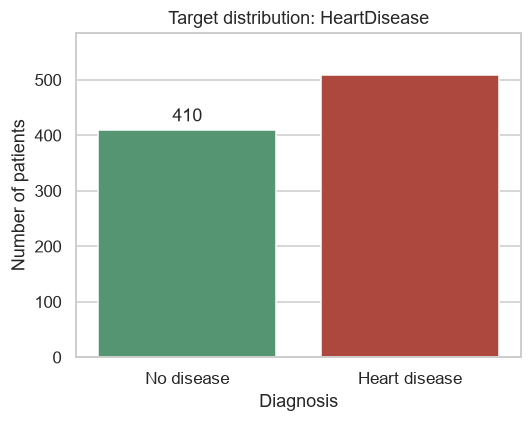

In [36]:
## Understanding distribution of target

## Count and percentage of each class
counts = df[target].value_counts().sort_index()
percent = (df[target].value_counts(normalize=True).sort_index() * 100).round(1)

print("No disease   :", counts[0], "patients (", percent[0], "% )")
print("Heart disease:", counts[1], "patients (", percent[1], "% )")
print("Majority-class baseline accuracy:", percent.max(), "%")

## Bar chart of the class balance
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=target, hue=target, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Target distribution: HeartDisease")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of patients")
ax.set_xticks([0, 1])
ax.set_xticklabels([LABELS[0], LABELS[1]])
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation.** The split is 508 disease-positive (55.3%) against 410 negative (44.7%), a ratio of about 1.24 : 1. That is mild enough that resampling, class weighting or SMOTE would be solving a problem that does not exist, and all three would distort the predicted probabilities that section 5's threshold selection depends on. No rebalancing is applied.

Two consequences follow. First, **the baseline every model must beat is 55.3% accuracy** — the score obtained by predicting "heart disease" for everyone. A model reporting 78% accuracy is beating a coin flip, not beating that trivial strategy, and only the gap between the two is a real claim. This baseline is reported alongside every model in sections 4 and 5.

Second, near-balance does not rescue accuracy as the headline metric. Balance makes accuracy *interpretable*; it does not make it *appropriate*. Accuracy scores a missed heart disease case and a false referral identically, when the first can end in a fatal cardiac event and the second ends in an unnecessary but survivable test. The metric choice in section 5 follows from that asymmetry, not from this ratio.

One caveat that limits deployment: 55.3% prevalence describes a **referred cardiology cohort**, not the general population, where prevalence is far lower. A model calibrated on this base rate will over-predict disease on unselected primary-care walk-ins. The threshold chosen in section 5 is valid for the referred population this dataset represents, and would need recalibration before wider use.

### 2.3.1.2 Understanding distribution of features

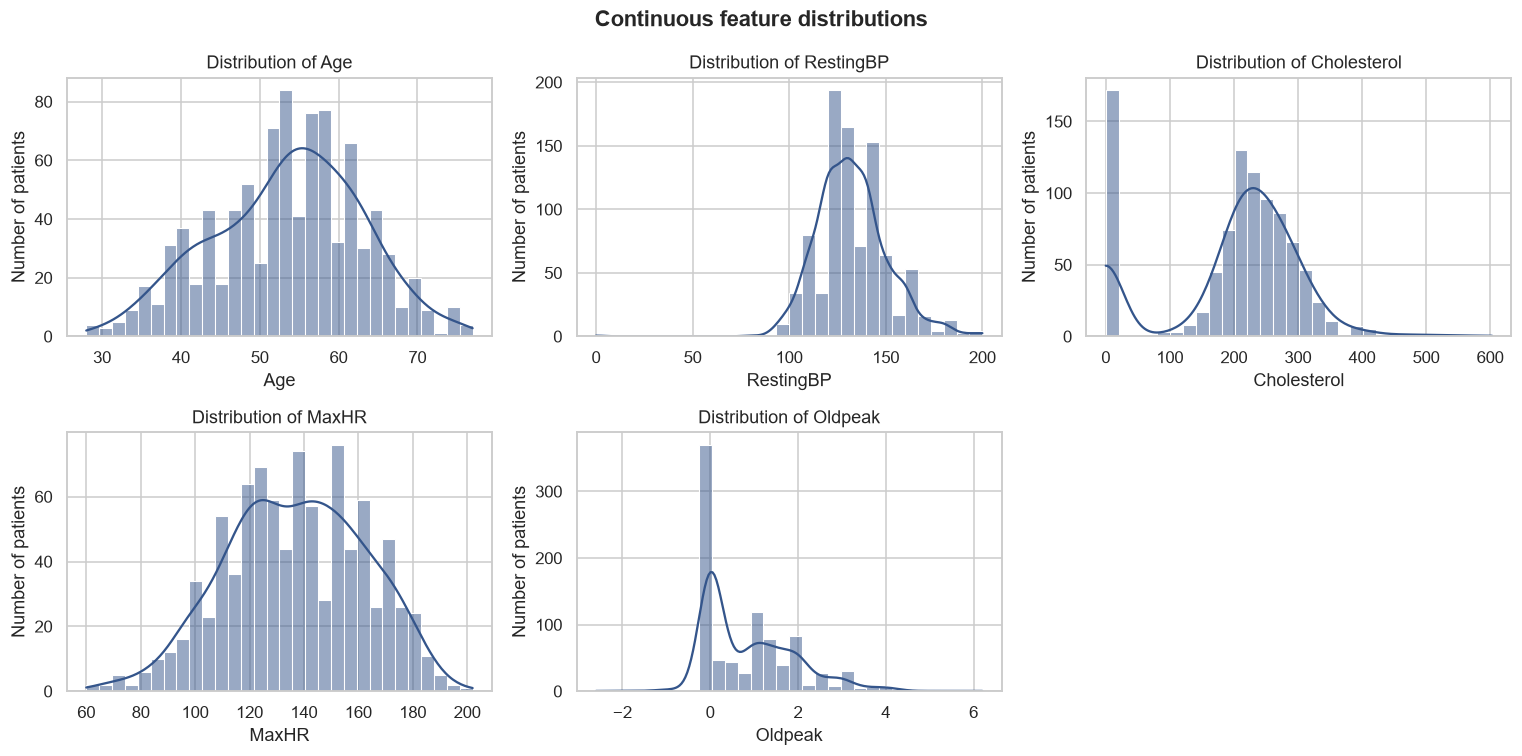

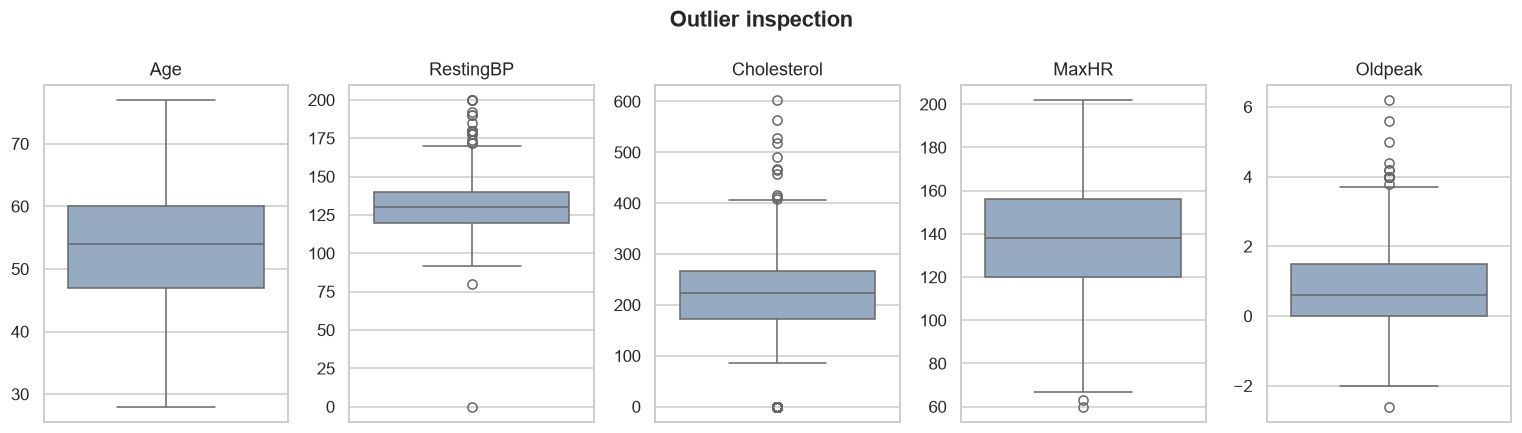

Outliers using the 1.5 x IQR rule:
Age : 0 rows ( 0.0 % )
RestingBP : 28 rows ( 3.1 % )
Cholesterol : 183 rows ( 19.9 % )
MaxHR : 2 rows ( 0.2 % )
Oldpeak : 16 rows ( 1.7 % )


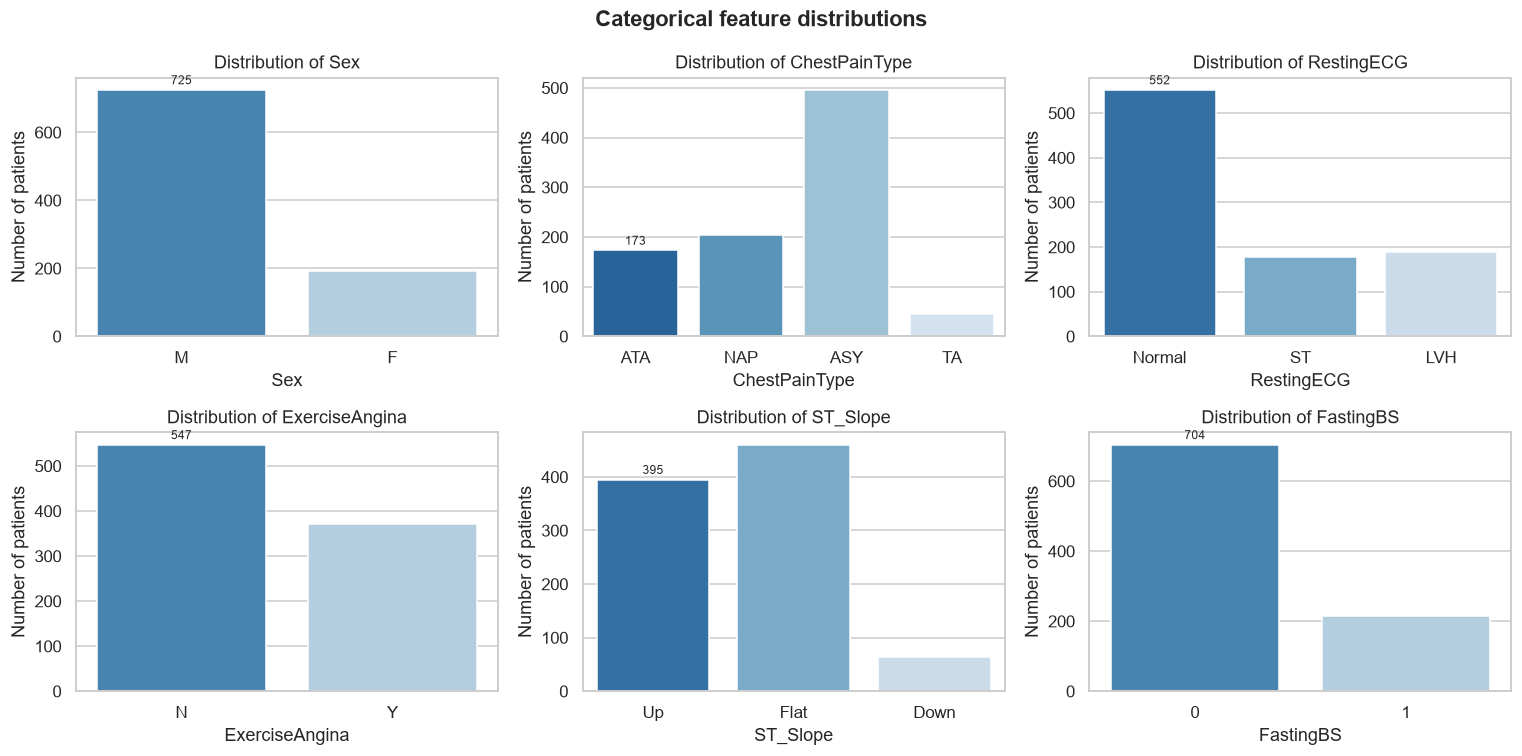

In [37]:
## Understanding distribution of features

## Histograms show the shape of each continuous feature and expose impossible values
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, color="#34558B", ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
axes[-1].axis("off")
fig.suptitle("Continuous feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots make outliers easy to see
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, color="#8FA9C9", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
fig.suptitle("Outlier inspection", fontweight="bold")
plt.tight_layout()
plt.show()

## Count the outliers so the discussion is based on numbers, not just the picture
print("Outliers using the 1.5 x IQR rule:")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## Bar charts for the categorical features, with counts labelled so rare levels stand out
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    sns.countplot(data=df, x=col, hue=col, palette="Blues_r", legend=False, ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
    axes[i].bar_label(axes[i].containers[0], fontsize=8, padding=2)
fig.suptitle("Categorical feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.**

`Age` is close to symmetric (skew −0.20), centred on a mean of 53.5 and spanning 28 to 77 — a plausible referral range with no absurd values and zero IQR outliers, so no transform is needed.

`Cholesterol` confirms the 2.2 finding visually: instead of one smooth distribution there is a **tall spike at exactly 0**, separated from an otherwise roughly normal body of measured values centred near 240. That spike is the 172 unmeasured patients, and it is what drives the counterintuitive negative skew (−0.61). There is also a genuine extreme at 603 mg/dl, which is clinically rare but real and should be kept rather than trimmed.

`RestingBP` has a single record at 0 mm Hg. Unlike the cholesterol zeros this is not a systematic collection gap but one data-entry error, so section 3.1 drops the row rather than imputing it.

`Oldpeak` is the only meaningfully skewed feature (skew 1.02), with a large stack at 0 (patients with no exercise-induced ST depression) and a few negative values. No log transform is applied: the zero is meaningful — it means no ST depression was observed — and a transform would destroy that interpretable anchor.

`MaxHR` is broadly symmetric across 60–202 bpm, consistent with an exercise stress test population.

Among the categoricals, the striking result is that **`ChestPainType` is dominated by `ASY` (asymptomatic) at 54.0%**. The largest single group in a cardiology cohort presented *without* classic chest pain. That undercuts any product built on symptom-led screening: a tool waiting for a patient to report chest pain would miss the majority of this population — which is precisely the argument for a model reading the full panel of markers instead.

`ST_Slope` is badly imbalanced across its levels: `Flat` 50.1%, `Up` 43.0%, but `Down` only 6.9% (≈63 patients). Any per-level estimate there will be high-variance, and it is a candidate for merging into `Flat` if section 4 shows instability. `ChestPainType = TA` is similarly thin at 5.0%.

**Implications for modelling.** Outlier counts are not uniformly small, and the pattern is informative rather than alarming. `Cholesterol` shows 183 outliers (19.9%) under the 1.5 × IQR rule, but these are not 183 independent anomalies — roughly 172 of them are the same disguised-missing zeros identified in 2.2, which fall far below the lower IQR bound and are flagged automatically, plus a handful of genuine high extremes including the 603 mg/dl maximum. `RestingBP` shows 28 outliers (3.1%), more than the single zero-entry error, and the remainder are better read as a normal hypertensive tail in a cardiology cohort than as data-quality noise. `Oldpeak` (16, 1.7%), `MaxHR` (2, 0.2%) and `Age` (0) are genuinely modest.

None of these are trimmed. The `Cholesterol` count is already addressed by the imputation-plus-flag decision from 2.2, and the rest are clinically plausible extreme values that tree ensembles are insensitive to — which is one argument for including Random Forest or Gradient Boosting in the model comparison. Outlier handling and missingness handling are therefore the same fix here, not two separate problems. The differing feature scales confirm that scaling is required for the distance- and gradient-based candidates, applied inside a pipeline to prevent leakage.

### 2.3.2 Understanding relationship between variables

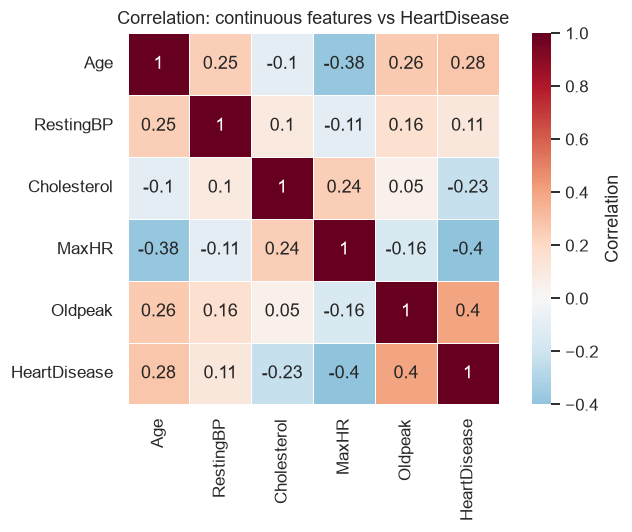

Correlation of each continuous feature with HeartDisease:
MaxHR         -0.40
Cholesterol   -0.23
RestingBP      0.11
Age            0.28
Oldpeak        0.40
Name: HeartDisease, dtype: float64


In [38]:
## Understanding relationship between variables

## Correlation between the continuous features and the target.
## Because HeartDisease is coded 0/1, pandas' Pearson correlation is exactly the
## point-biserial correlation, so no extra library is needed.
corr = df[numeric_cols + [target]].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation: continuous features vs HeartDisease")
plt.tight_layout()
plt.show()

print("Correlation of each continuous feature with HeartDisease:")
print(corr[target].drop(target).sort_values())

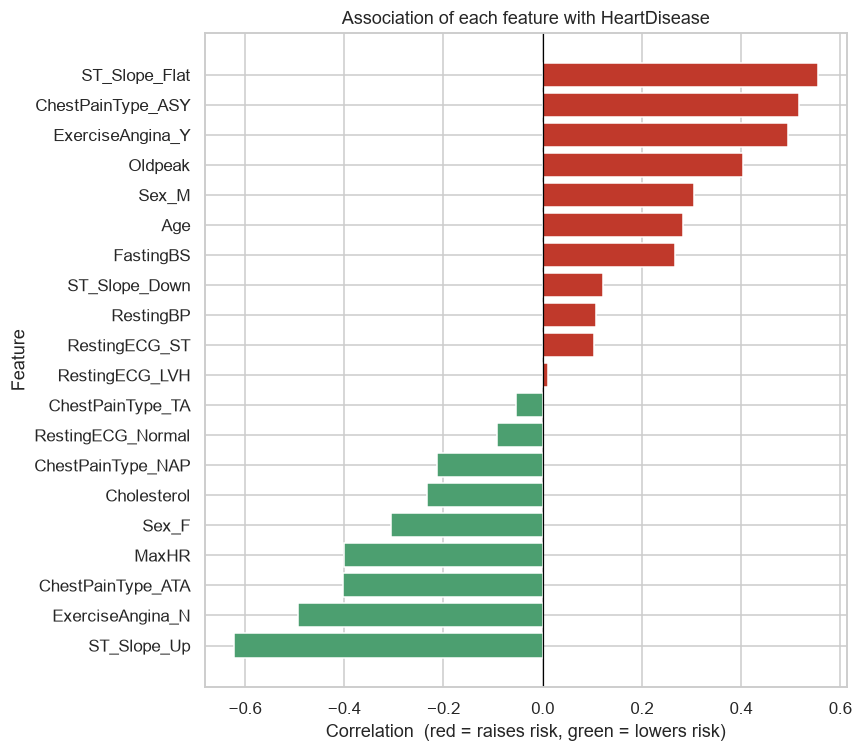

In [39]:
## One-hot encode so that categorical levels can be ranked on the same scale as the
## numeric columns. This is a quick stand-in for feature importance before any model
## is trained, and tells us which features are worth engineering.
encoded = pd.get_dummies(df.drop(columns=[target])).astype(float)
strength = encoded.corrwith(df[target]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colours = ["#4C9F70" if v < 0 else "#C0392B" for v in strength]
ax.barh(strength.index, strength.values, color=colours)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Association of each feature with HeartDisease")
ax.set_xlabel("Correlation  (red = raises risk, green = lowers risk)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

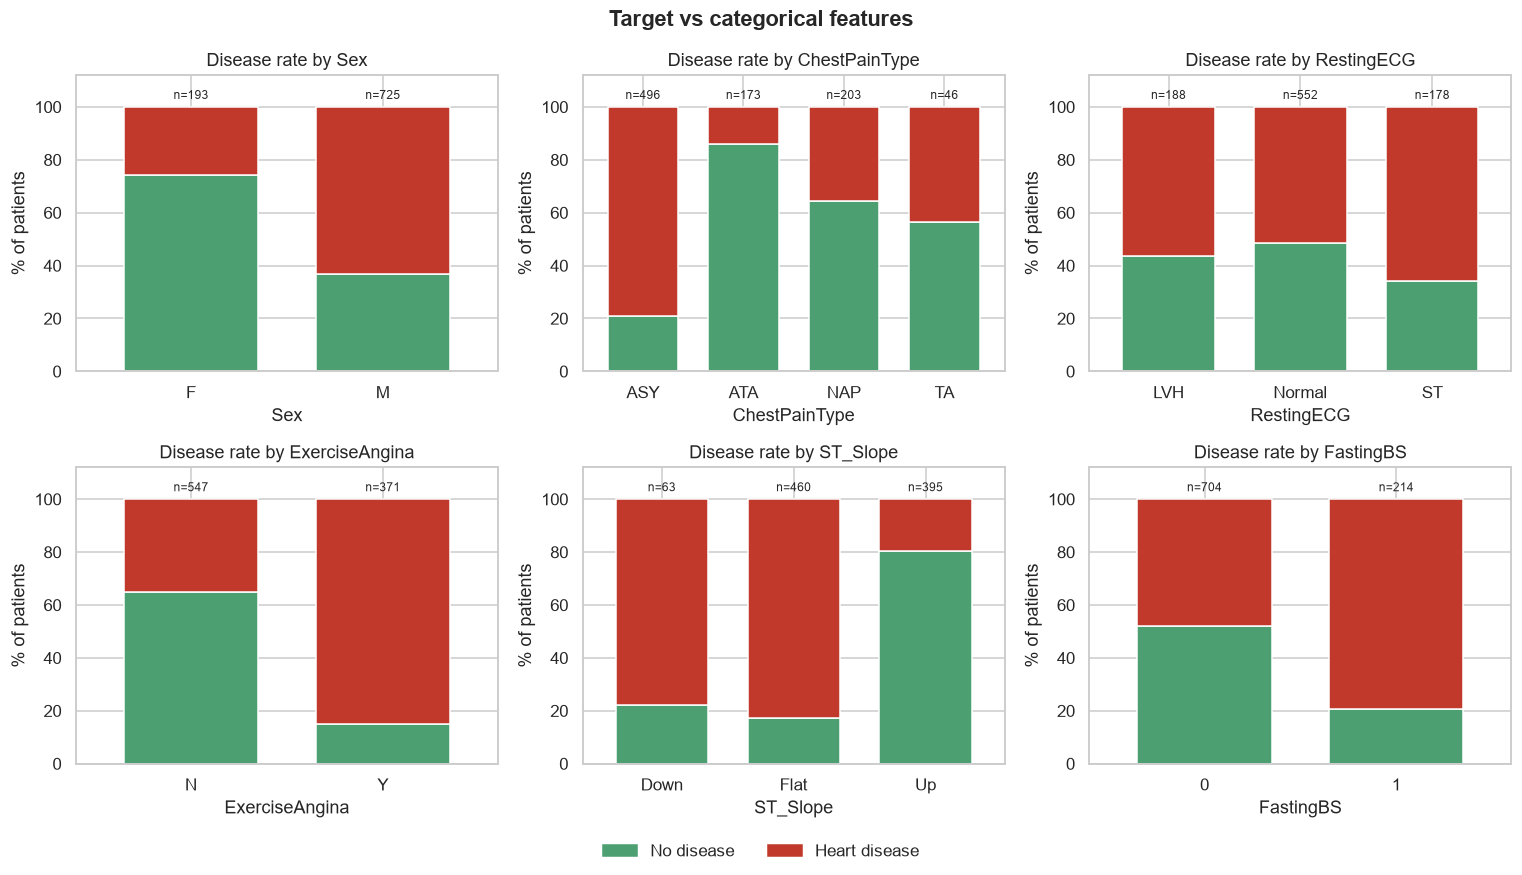

In [40]:
## Stacked percentage bars show how strongly each category splits the target.
## Sample size is printed above each bar because a large effect on a small group
## is not trustworthy.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    share = pd.crosstab(df[col], df[target], normalize="index") * 100
    share.plot(kind="bar", stacked=True, ax=axes[i], legend=False,
               color=[PALETTE[0], PALETTE[1]], width=0.7)
    axes[i].set_title("Disease rate by " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].set_ylim(0, 112)
    for j, level in enumerate(share.index):
        axes[i].text(j, 103, "n=" + str((df[col] == level).sum()), ha="center", fontsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]),
           plt.Rectangle((0, 0), 1, 1, color=PALETTE[1])]
fig.legend(handles, [LABELS[0], LABELS[1]], loc="lower center", ncol=2, frameon=False)
fig.suptitle("Target vs categorical features", fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

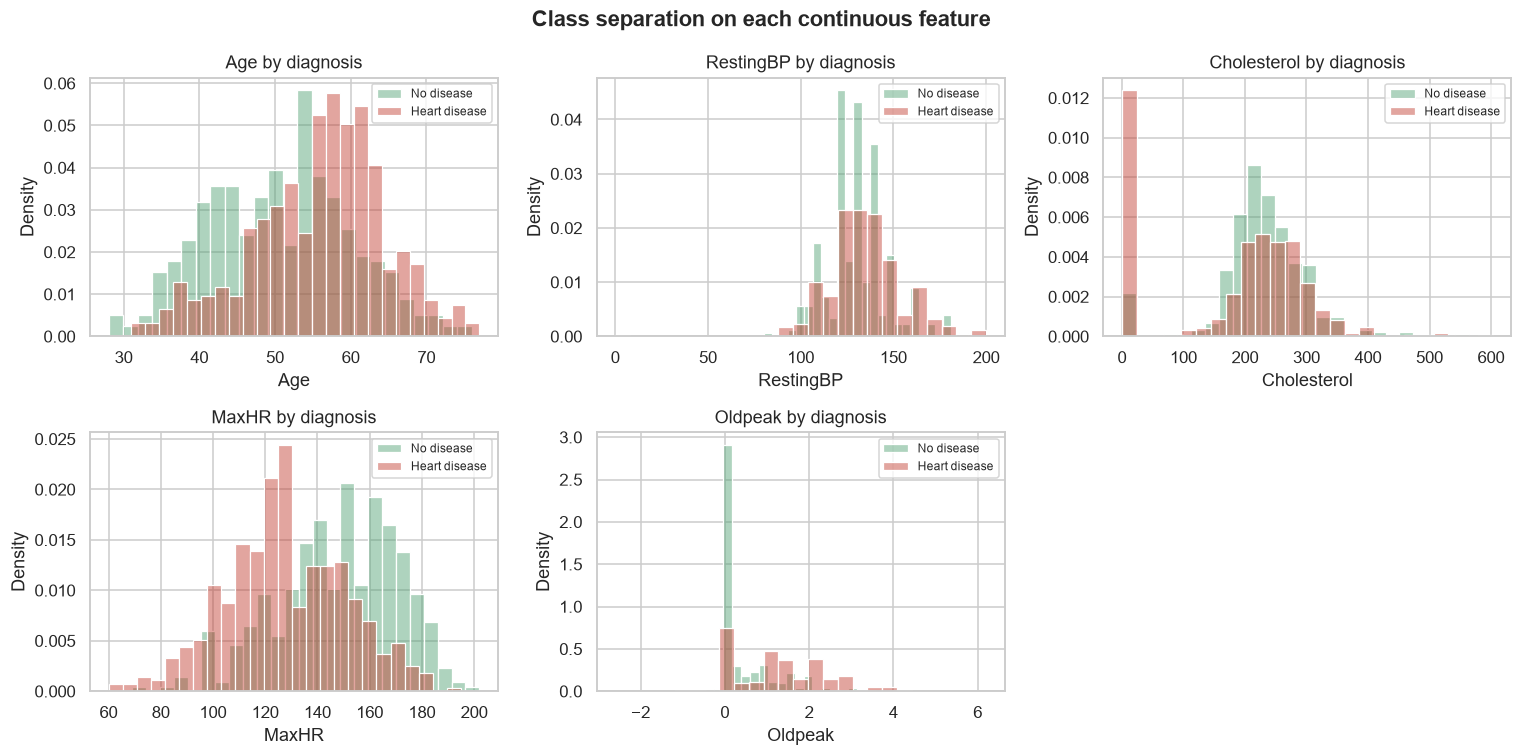

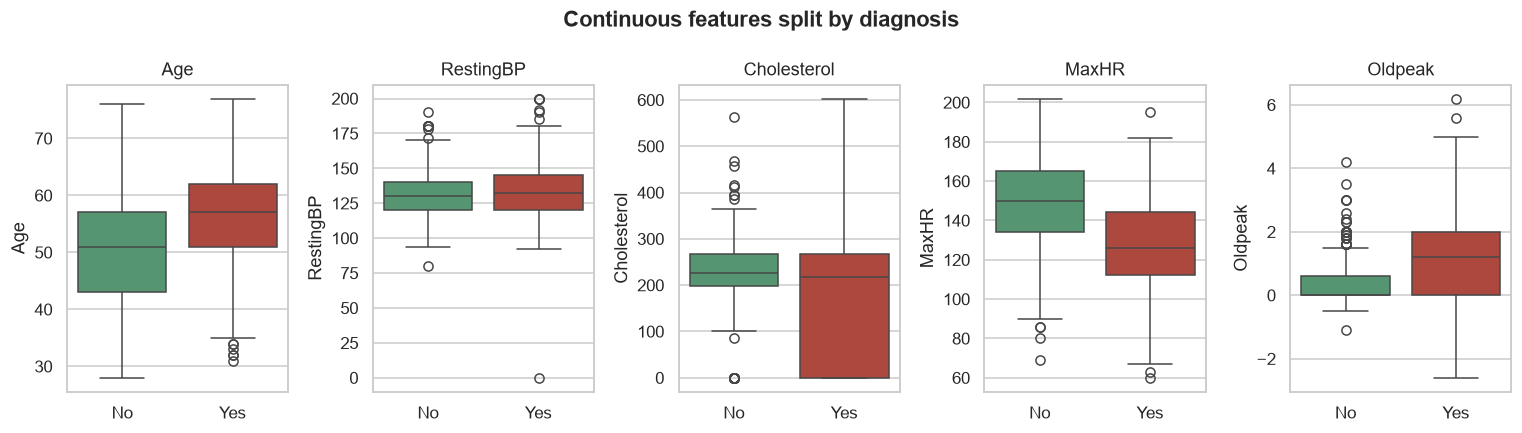

In [41]:
## Overlaid histograms show how much the two classes overlap on each feature.
## Heavy overlap means the model cannot separate patients on that feature alone.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    for cls in [0, 1]:
        sns.histplot(data=df[df[target] == cls], x=col, bins=25, stat="density",
                     alpha=0.45, color=PALETTE[cls], label=LABELS[cls], ax=axes[i])
    axes[i].set_title(col + " by diagnosis")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
fig.suptitle("Class separation on each continuous feature", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots of the same comparison, which make the shift in medians easier to read
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target, y=col, hue=target, palette=PALETTE,
                legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])
fig.suptitle("Continuous features split by diagnosis", fontweight="bold")
plt.tight_layout()
plt.show()

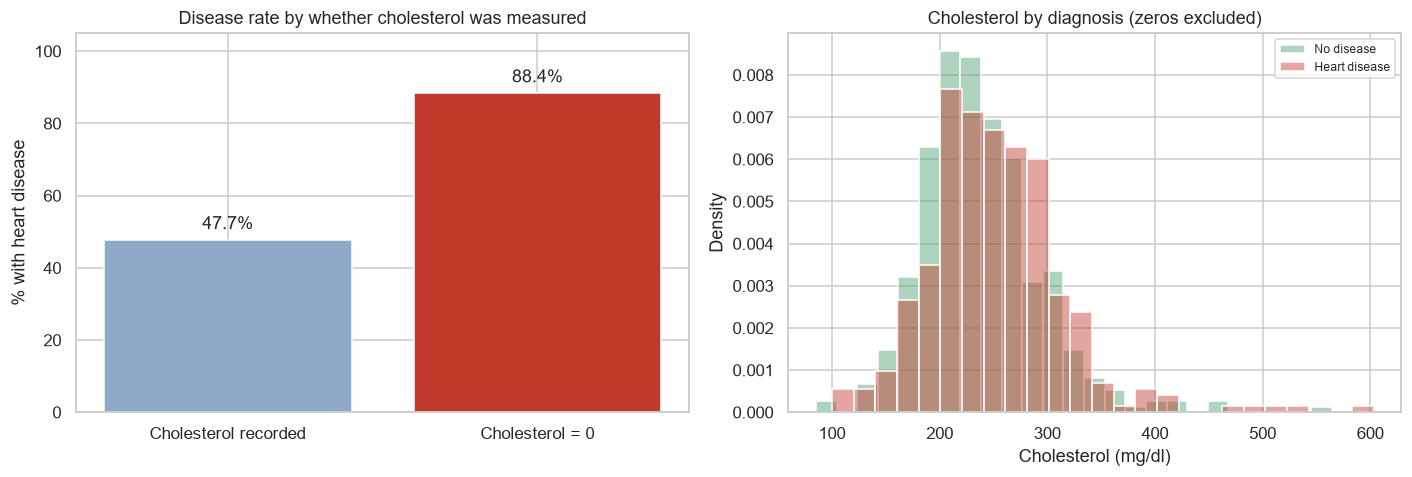

In [42]:
## Left: disease rate depending only on whether cholesterol was recorded.
## Right: the cholesterol distribution once the disguised zeros are excluded.
## Together these show that the zeros carry outcome information that has nothing
## to do with a patient's actual cholesterol level.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rate = df.groupby(df["Cholesterol"] == 0)[target].mean() * 100
axes[0].bar(["Cholesterol recorded", "Cholesterol = 0"], rate.values,
            color=["#8FA9C9", "#C0392B"])
axes[0].set_title("Disease rate by whether cholesterol was measured")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 3, str(round(v, 1)) + "%", ha="center")

measured = df[df["Cholesterol"] > 0]
for cls in [0, 1]:
    sns.histplot(data=measured[measured[target] == cls], x="Cholesterol", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[1])
axes[1].set_title("Cholesterol by diagnosis (zeros excluded)")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

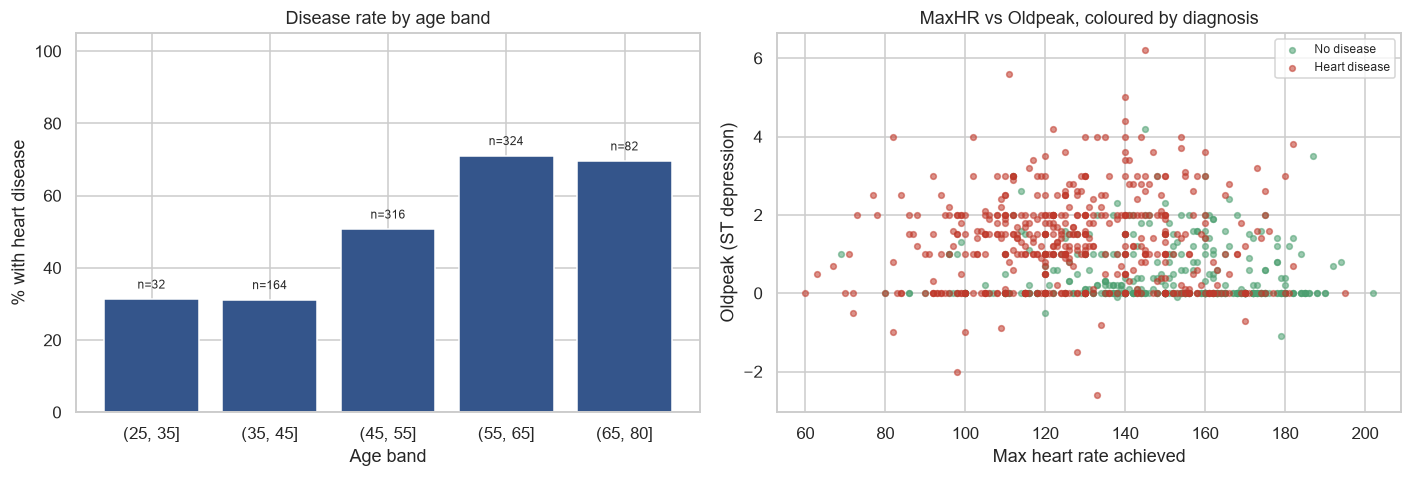

In [43]:
## Disease rate across age bands, which is easier for a non-technical audience
## to read than a correlation coefficient
bands = pd.cut(df["Age"], bins=[25, 35, 45, 55, 65, 80])
by_age = df.groupby(bands, observed=True)[target].agg(["mean", "size"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(by_age.index.astype(str), by_age["mean"] * 100, color="#34558B")
axes[0].set_title("Disease rate by age band")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, row in enumerate(by_age.itertuples()):
    axes[0].text(i, row.mean * 100 + 3, "n=" + str(row.size), ha="center", fontsize=8)

## Two features plotted together, to see whether the classes separate in 2D.
## This gives an early feel for how complex a decision boundary the model needs.
for cls in [0, 1]:
    subset = df[df[target] == cls]
    axes[1].scatter(subset["MaxHR"], subset["Oldpeak"], s=14, alpha=0.55,
                    color=PALETTE[cls], label=LABELS[cls])
axes[1].set_title("MaxHR vs Oldpeak, coloured by diagnosis")
axes[1].set_xlabel("Max heart rate achieved")
axes[1].set_ylabel("Oldpeak (ST depression)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

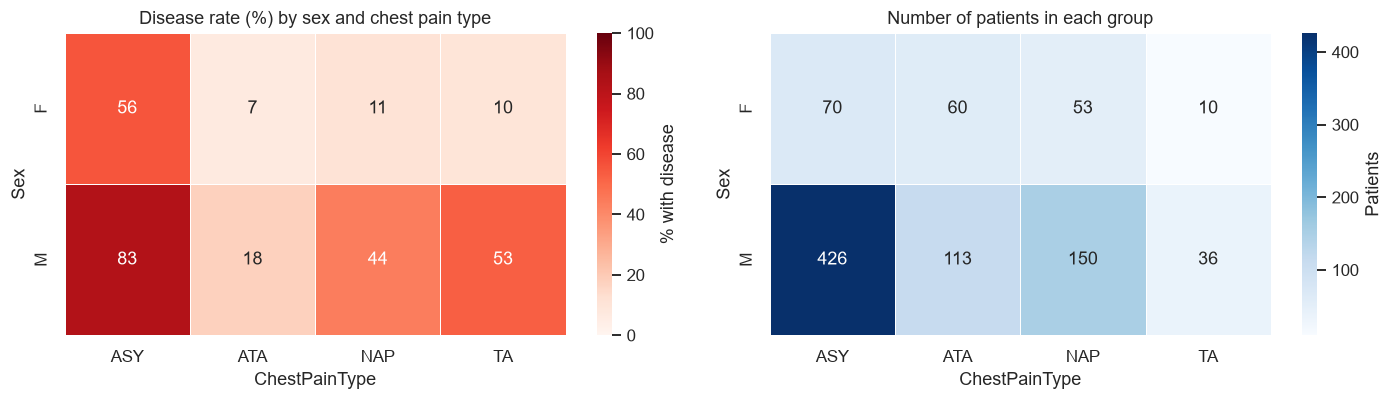

Strongest correlations between predictors:
Age          Age          1.00
MaxHR        Age          0.38
Age          Oldpeak      0.26
             RestingBP    0.25
Cholesterol  MaxHR        0.24
Oldpeak      RestingBP    0.16
dtype: float64


In [44]:
## Disease rate for each Sex x ChestPainType combination, with the number of patients
## in each cell. Small cells warn us where the model's performance estimate will be
## unreliable and where a headline metric hides poor performance.
rate_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="mean") * 100
size_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="size")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(rate_table, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={"label": "% with disease"}, ax=axes[0])
axes[0].set_title("Disease rate (%) by sex and chest pain type")

sns.heatmap(size_table, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Patients"}, ax=axes[1])
axes[1].set_title("Number of patients in each group")

plt.tight_layout()
plt.show()

## Finally, check whether any two continuous predictors carry the same information
print("Strongest correlations between predictors:")
print(df[numeric_cols].corr().abs().unstack().sort_values(ascending=False)
        .drop_duplicates().head(6).round(2))

### 2.3.3 What the relationships mean for the model

**`ST_Slope` is the strongest single predictor.** Upsloping patients are overwhelmingly disease-negative; flat-sloped patients are overwhelmingly disease-positive — a cleaner split than any other feature achieves. But this needs stating plainly: `ST_Slope`, `Oldpeak`, `MaxHR` and `ExerciseAngina` all come from an **exercise stress test**. The features carrying most of the model's signal are not available at a walk-in consultation. That sharpens assumption 1 considerably — this model describes a patient who has *already* been escalated to a stress test, and predicts the diagnosis that test is working toward. Section 4 therefore trains a second, reduced "pre-stress-test" model using only age, sex, chest pain type, resting blood pressure, cholesterol and fasting blood sugar, and reports both. A model that only works after the expensive test has been run is a weaker product than section 1 implies, and the honest response is to quantify the gap rather than hide it.

**Asymptomatic chest pain is the highest-risk category, not the lowest.** `ASY` patients show a far higher disease rate than those reporting atypical angina (`ATA`), and `ASY` is simultaneously the largest group at 54.0% of the cohort. The patients most likely to be sick are the ones least likely to complain of the textbook symptom. This is the strongest evidence in the EDA for the product's core value: a signal-driven triage aid catches exactly the group that symptom-led judgement tends to reassure and send home.

**Class separation is real but no single feature is sufficient.** Among the continuous predictors, `Oldpeak` (+0.40) and `MaxHR` (−0.40) correlate most strongly with the target, followed by `Age` (+0.28); `Cholesterol` (−0.23) and `RestingBP` (+0.11) are weak. Note that the `Cholesterol` correlation is not trustworthy on its own — it is contaminated by the missingness artefact rather than measuring a physiological relationship. The overlaid histograms show `Oldpeak` and `MaxHR` shifting clearly between classes while `Age`, `RestingBP` and `Cholesterol` overlap heavily, so a univariate rule would perform poorly and a multivariate model is justified. The `MaxHR` vs `Oldpeak` scatter shows partial separation with a substantial mixed region in the middle — the classes are not cleanly linearly separable, which predicts that tree ensembles will edge out logistic regression, and that a meaningful share of patients will sit near the decision boundary with probabilities close to 0.5. Those borderline patients are exactly where the threshold decision in section 5 does its work.

**The cholesterol plot pair isolates the leakage risk.** The left panel shows the disease rate depending *only* on whether the test was recorded: 47.7% when measured against 88.4% when the value reads 0 — a 40-point gap that has nothing to do with any patient's actual cholesterol. The right panel shows that once the zeros are excluded, real cholesterol level separates the classes only weakly. The conclusion is uncomfortable but clear: the *presence* of the measurement is more predictive than the measurement itself. Any model that mean-imputes without a missingness flag will score well on this dataset and fail in deployment, because it will have learned a hospital-collection artefact rather than physiology.

**Age raises risk steadily but modestly**, consistent with its +0.28 correlation, and the youngest and oldest bands rest on small sample sizes, so those rates should not be over-read.

**Subgroup sizes limit what a single metric can claim.** The sex × chest pain heatmaps show several combinations with very few patients — notably female patients outside the `ASY` category. With women making up only 21.0% of the sample, a headline recall figure computed over all 918 rows is dominated by the male majority and can conceal poor performance on these thin cells. Section 5 reports metrics broken down by sex rather than assuming the overall figure applies to both.

**No multicollinearity concern.** The strongest predictor pair is `Age` and `MaxHR` at |r| = 0.38, with everything else below 0.26, so the features carry largely independent information. This supports keeping logistic regression as a candidate: its coefficients can be read as meaningful contributions rather than unstable estimates split across correlated columns. In a clinical setting, a model a doctor can interrogate has value beyond its score, and section 4's selection rationale weighs interpretability alongside raw performance.

**Decisions carried into section 3:**

1. Drop the single `RestingBP = 0` record as a data-entry error; retain all other outliers as clinically plausible.
2. Treat `Cholesterol = 0` as missing, impute it, and add a `Cholesterol_missing` flag so the collection artefact is used explicitly instead of corrupting the cholesterol feature.
3. One-hot encode the categorical columns; consider merging `ST_Slope = Down` into `Flat` if its 6.9% share proves unstable.
4. Scale continuous features inside a `Pipeline`, for the scaling-sensitive models only.
5. Stratify the train-test split on `HeartDisease` to preserve the 55.3 / 44.7 ratio.
6. Report the 55.3% majority-class baseline beside every model result, and report metrics separately by sex.
7. Train and report a reduced "pre-stress-test" feature set alongside the full model, to quantify how much of the performance depends on stress-test-derived features.

# 3. Data Preparation

Section 2 ended with a numbered list of decisions. This section carries each of them out, in the order they need to happen:

| Step | What it does | Which 2.3.3 decision it implements |
| --- | --- | --- |
| 3.1 Data Cleaning | remove the impossible `RestingBP` record, convert disguised missing values to `NaN` | 1, 2 (first half) |
| 3.2 Feature Engineering | build the missingness flag and three clinically-motivated derived features | 2 (second half) |
| 3.3 Feature Selection | define the full and reduced "pre-stress-test" feature sets | 7 |
| 3.4 Preprocessing Pipeline | encode, impute and scale — fitted inside a `Pipeline` so nothing leaks | 3, 4 |
| 3.5 Train-Test Split | stratified hold-out that preserves the class ratio | 5 |

**The ordering matters and is deliberate.** Row-level repairs that depend on no statistics at all (dropping a corrupt record, marking a 0 as missing) happen before the split, because they would be applied identically to any future patient and involve no information from other rows. Everything that *learns a value from the data* — imputation medians, scaling means, category vocabularies — is deferred into a `Pipeline` in 3.4 and fitted only on training folds. Doing the imputation eagerly here would leak the test set's cholesterol distribution into training and inflate every score reported in section 5.

## 3.1 Data Cleaning

In [45]:
## Work on a copy so that df_raw stays available for before/after comparison
data = df.copy()

## --- Step 1: remove the physiologically impossible RestingBP record ---
## Section 2.3.1.2 identified exactly one patient with RestingBP = 0 mm Hg. This is a
## data-entry error rather than a systematic collection gap, so the row is dropped.
## Only one row is lost, so the cost to sample size is negligible.
before = len(data)
data = data[data["RestingBP"] > 0].copy()
print("Rows dropped for RestingBP = 0:", before - len(data))

## --- Step 2: convert disguised missing cholesterol values to NaN ---
## A serum cholesterol of 0 means the lipid panel was never drawn, not that the patient
## has no cholesterol. Marking these as NaN stops the value 0 being treated as a real
## measurement, and hands the imputation decision to the pipeline in 3.4 where it can
## be fitted on training data only.
print("Cholesterol values converted to NaN:", (data["Cholesterol"] == 0).sum())
data["Cholesterol"] = data["Cholesterol"].replace(0, np.nan)

## --- Step 3: confirm no duplicate patient records ---
## The dataset compiler already removed 272 duplicates, so this is a safety check
## rather than an expected fix.
print("Duplicate rows remaining:", data.duplicated().sum())

## --- Step 4: negative Oldpeak values ---
## Oldpeak is ST depression, so a negative reading indicates ST elevation or a
## sign convention difference in one of the source cohorts. These are left as-is:
## they are a small minority, they are ordered correctly relative to 0, and both
## tree ensembles and a scaled logistic regression handle the sign without issue.
print("Negative Oldpeak records retained:", (data["Oldpeak"] < 0).sum())

## --- Cleaning summary ---
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning: ", data.shape)
print("\nMissing values after cleaning:")
print(data.isna().sum()[data.isna().sum() > 0])

Rows dropped for RestingBP = 0: 1
Cholesterol values converted to NaN: 171
Duplicate rows remaining: 0
Negative Oldpeak records retained: 13

Shape before cleaning: (918, 12)
Shape after cleaning:  (917, 12)

Missing values after cleaning:
Cholesterol    171
dtype: int64


**What was and was not removed, and why.**

`RestingBP = 0` is dropped outright. A resting blood pressure of zero is incompatible with a living patient, it appears exactly once, and there is no principled value to impute it with — a single row is a cheaper loss than a fabricated one.

`Cholesterol = 0` is *not* dropped, and this is the more consequential call. Section 2.2.1 counted 172 such records; 171 are converted here, because one of them belonged to the same patient as the impossible `RestingBP` reading and was already removed by the previous step. That single overlap is itself a small piece of evidence that these are data-collection failures clustering on particular records rather than independent measurement noise.

Those 171 records are close to a fifth of the dataset, and section 2.2.1 showed they are heavily disease-positive relative to the measured records (88.4% against 47.7%). Deleting them would discard a large block of patients non-randomly with respect to the target, shifting the class balance and biasing every downstream estimate. Converting them to `NaN` keeps the patients, removes the false measurement, and defers the imputation to a pipeline step that never sees the test set.

The 13 negative `Oldpeak` values are retained deliberately. They are few, and unlike a cholesterol of zero they are not impossible — they reflect ST elevation or a sign convention difference between the merged source cohorts. Clipping them to zero would erase a genuine distinction between "no ST depression" and "ST elevation", and none of the three chosen models require non-negative inputs.

Outliers flagged by the IQR rule in 2.3.1.2 are also retained. As established there, the large `Cholesterol` count was mostly the disguised zeros — now handled — and the `RestingBP` tail is a plausible hypertensive population rather than corruption. Trimming clinically real extreme values would remove exactly the high-risk patients this model exists to catch.

After this step the shape is 917 x 12, and the only remaining missing values sit in `Cholesterol`, which is intended: they are now honestly marked and handled in 3.4.

## 3.2 Feature Engineering

In [46]:
## Feature engineering is applied to the cleaned frame. Every feature below is
## computed from a single patient's own record, so it can be recomputed identically
## at prediction time in the Streamlit app and introduces no cross-row leakage.

## --- Feature 1: Cholesterol_missing ---
## Section 2.2.1 found that whether a lipid panel was drawn is more predictive than
## the value it returned. Making this explicit lets the model use the fact openly
## instead of inferring it from an imputed cholesterol value, and keeps the imputed
## column interpretable as an actual cholesterol estimate.
data["Cholesterol_missing"] = data["Cholesterol"].isna().astype(int)

## --- Feature 2: HR_reserve_deficit ---
## Age-predicted maximum heart rate is conventionally 220 - age. The shortfall between
## that prediction and the rate the patient actually achieved is a measure of
## chronotropic incompetence, a recognised marker of cardiac impairment. This combines
## Age and MaxHR into one clinically meaningful quantity; section 2.3.2 showed the two
## are the most correlated predictor pair (|r| = 0.38), so a ratio-style term captures
## their interaction that neither column expresses alone.
data["HR_reserve_deficit"] = (220 - data["Age"]) - data["MaxHR"]

## --- Feature 3: HasSTDepression ---
## Oldpeak is heavily zero-inflated: a large block of patients have no ST depression at
## all, and the remainder spread over a continuous range. A linear model cannot express
## "any depression at all" as distinct from "how much"; this flag separates the two so
## logistic regression can weight the threshold effect and the magnitude effect
## independently.
data["HasSTDepression"] = (data["Oldpeak"] > 0).astype(int)

## --- Feature 4: BP_category ---
## Resting blood pressure correlated only weakly with the target as a raw number
## (r = 0.11), which is expected: clinical risk rises in steps at recognised
## thresholds rather than linearly per mm Hg. Binning to the standard hypertension
## stages gives a linear model access to that step structure.
data["BP_category"] = pd.cut(
    data["RestingBP"],
    bins=[0, 120, 130, 140, 300],
    labels=["Normal", "Elevated", "Stage1", "Stage2"],
)

print("Engineered features added:")
print(data[["Cholesterol_missing", "HR_reserve_deficit", "HasSTDepression", "BP_category"]].head())
print("\nNew shape:", data.shape)

Engineered features added:
   Cholesterol_missing  HR_reserve_deficit  HasSTDepression BP_category
0                    0                   8                0      Stage1
1                    0                  15                1      Stage2
2                    0                  85                0    Elevated
3                    0                  64                1      Stage1
4                    0                  44                0      Stage2

New shape: (917, 16)


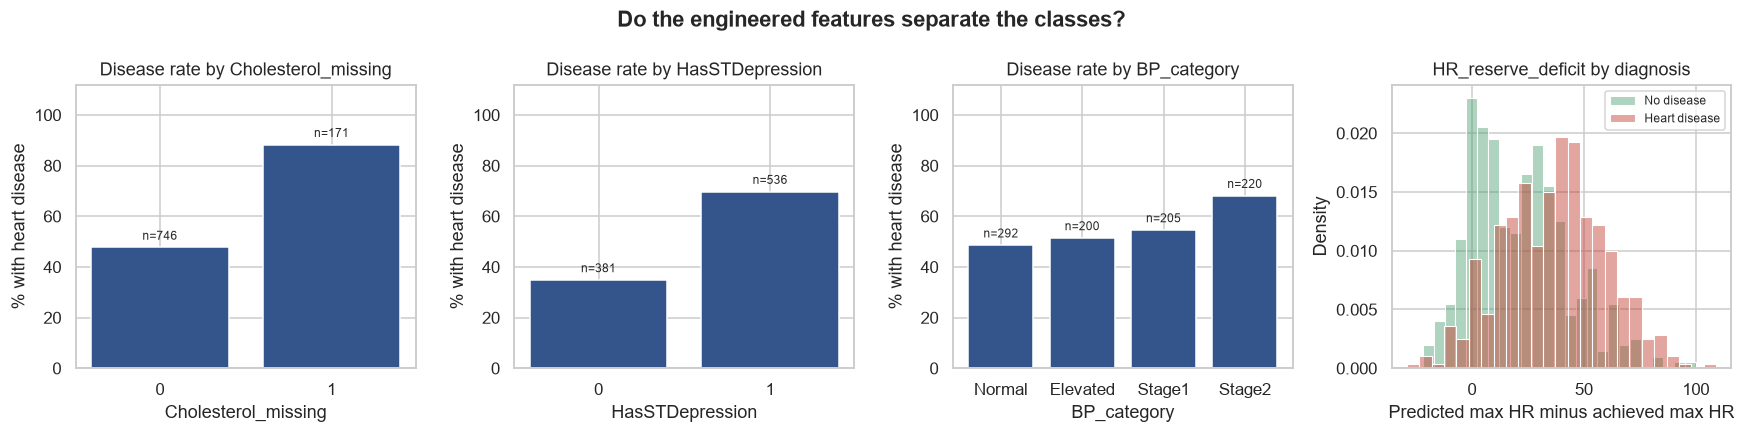

Correlation with HeartDisease -- engineered vs source features:
  Cholesterol_missing    r = +0.318   (source Cholesterol  r = +0.104)
  HR_reserve_deficit     r = +0.321   (source MaxHR        r = -0.401)
  HasSTDepression        r = +0.346   (source Oldpeak      r = +0.404)
  BP_category_code       r = +0.141   (source RestingBP    r = +0.118)


In [47]:
## Check that each engineered feature actually separates the classes, rather than
## assuming it does. A feature that does not move the disease rate is not worth keeping.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

## Three binary/categorical features: disease rate per level, with group sizes
for ax, col in zip(axes[:3], ["Cholesterol_missing", "HasSTDepression", "BP_category"]):
    rate = data.groupby(col, observed=True)[target].mean() * 100
    size = data.groupby(col, observed=True)[target].size()
    ax.bar(rate.index.astype(str), rate.values, color="#34558B")
    ax.set_title("Disease rate by " + col)
    ax.set_xlabel(col)
    ax.set_ylabel("% with heart disease")
    ax.set_ylim(0, 112)
    for i, (v, n) in enumerate(zip(rate.values, size.values)):
        ax.text(i, v + 3, "n=" + str(n), ha="center", fontsize=8)

## One continuous feature: distribution split by class
for cls in [0, 1]:
    sns.histplot(data=data[data[target] == cls], x="HR_reserve_deficit", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[3])
axes[3].set_title("HR_reserve_deficit by diagnosis")
axes[3].set_xlabel("Predicted max HR minus achieved max HR")
axes[3].set_ylabel("Density")
axes[3].legend(fontsize=8)

fig.suptitle("Do the engineered features separate the classes?", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify the same thing, so the rationale rests on numbers rather than the picture.
## Each engineered feature is compared against the raw column it was derived from.
print("Correlation with HeartDisease -- engineered vs source features:")
check = data.copy()
check["BP_category_code"] = check["BP_category"].cat.codes
pairs = [
    ("Cholesterol_missing", "Cholesterol"),
    ("HR_reserve_deficit", "MaxHR"),
    ("HasSTDepression", "Oldpeak"),
    ("BP_category_code", "RestingBP"),
]
for new, source in pairs:
    r_new = check[new].corr(check[target])
    r_src = check[source].corr(check[target])
    print(f"  {new:22} r = {r_new:+.3f}   (source {source:12} r = {r_src:+.3f})")

**Rationale for each engineered feature, and what the evidence actually shows.**

The correlation table above compares each engineered feature against the raw column it was derived from. The results are mixed, and reporting them honestly is more useful than claiming four uniform wins:

| Engineered feature | r with target | Source column | r with target | Verdict |
| --- | --- | --- | --- | --- |
| `Cholesterol_missing` | +0.318 | `Cholesterol` | +0.104 | much stronger than its source |
| `HR_reserve_deficit` | +0.321 | `MaxHR` | −0.401 | weaker than its source |
| `HasSTDepression` | +0.346 | `Oldpeak` | +0.404 | weaker than its source |
| `BP_category` | +0.141 | `RestingBP` | +0.118 | marginally stronger |

**The cleaning step has already produced a significant result, visible in the first row.** In section 2.3.2, raw `Cholesterol` correlated with the target at **−0.23** — an apparently protective effect, where higher cholesterol looked associated with *less* heart disease. That was never plausible clinically. With the disguised zeros converted to `NaN`, the correlation on genuinely measured patients is **+0.104**: weak, but pointing the expected direction. The entire negative correlation reported in section 2 was an artefact of 172 unmeasured patients being read as having near-zero cholesterol. This is direct confirmation that the imputation-plus-flag decision was necessary rather than cautious, and it is the clearest demonstration in the notebook of why a disguised missing value is more dangerous than an obvious one — it does not merely add noise, it inverts the sign of a relationship.

`Cholesterol_missing` at +0.318 is now the second-strongest single signal in the feature set, above every raw clinical measurement except `Oldpeak` and `MaxHR`. That is precisely the artefact section 2.2.1 warned about, now made explicit rather than hidden. Keeping it visible serves two purposes: the model uses the signal openly instead of reconstructing it from an oddly-imputed cholesterol value, and section 4's feature importances will show exactly how heavily the model leans on it — which is a limitation to be discussed, not concealed.

**`HR_reserve_deficit` and `HasSTDepression` are both weaker than their sources, and are kept for a different reason.** A lower correlation is not the same as no value. Both are *reparameterisations* that expose structure a linear model cannot otherwise reach, not replacements:

- `HR_reserve_deficit` (+0.321 vs `MaxHR` at −0.401) folds `Age` and `MaxHR` into one clinically meaningful quantity. A 60-year-old and a 40-year-old both reaching 150 bpm are very different patients, but identical to a model reading `MaxHR` alone. Pearson correlation measures only the linear association of a single column and cannot capture that interaction, so a lower r here does not mean less information — it means the information is of a kind this statistic does not see.
- `HasSTDepression` (+0.346 vs `Oldpeak` at +0.404) is necessarily weaker, because collapsing a continuous variable to a binary flag discards magnitude by construction. Its purpose is the zero-inflation visible in the 2.3.1.2 histogram: logistic regression must assume a constant effect per unit of `Oldpeak` and cannot express "any depression at all is a warning sign, separately from how much". The trees can find that threshold themselves, so this feature is expected to matter for logistic regression and to be largely redundant for Random Forest and Gradient Boosting.

Because both retain their source columns, neither can destroy information — the worst case is that section 4's feature importances rank them near zero, which is itself a reportable finding rather than a cost.

`BP_category` (+0.141 vs +0.118) is a marginal gain, consistent with the reasoning that clinical risk rises in steps at guideline thresholds rather than linearly per mm Hg. The bins follow the standard ACC/AHA hypertension stages (normal <120, elevated 120–129, stage 1 130–139, stage 2 ≥140), so the cut points are externally defined rather than fitted to this data — which also means they carry no risk of having been tuned to the target.

Nothing is dropped at this stage. The engineered columns sit alongside their sources, section 4 reports importances for all of them, and feature selection proper is handled in 3.3 on availability grounds rather than statistical ones.

## 3.3 Feature Selection

In [48]:
## Two feature sets are defined, corresponding to two deployment scenarios.

## The target and the columns that will not be fed to any model
X_full = data.drop(columns=[target])
y = data[target]

## --- Feature set A: full ---
## Everything available, including the four measurements derived from an exercise
## stress test. This is the model for a patient already undergoing cardiac workup.
features_full = X_full.columns.tolist()

## --- Feature set B: reduced, "pre-stress-test" ---
## Section 2.3.3 established that ST_Slope, Oldpeak, MaxHR and ExerciseAngina all come
## from an exercise stress test, which is not available at a first consultation. Any
## feature derived from those is excluded too, which removes HR_reserve_deficit and
## HasSTDepression. What remains is history, a resting ECG and a blood panel.
stress_test_features = [
    "ST_Slope", "Oldpeak", "MaxHR", "ExerciseAngina",
    "HR_reserve_deficit", "HasSTDepression",
]
features_reduced = [c for c in features_full if c not in stress_test_features]

print("Full feature set (", len(features_full), "features ):")
print(" ", features_full)
print("\nReduced pre-stress-test feature set (", len(features_reduced), "features ):")
print(" ", features_reduced)
print("\nExcluded from the reduced set:")
print(" ", stress_test_features)

Full feature set ( 15 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Cholesterol_missing', 'HR_reserve_deficit', 'HasSTDepression', 'BP_category']

Reduced pre-stress-test feature set ( 9 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'Cholesterol_missing', 'BP_category']

Excluded from the reduced set:
  ['ST_Slope', 'Oldpeak', 'MaxHR', 'ExerciseAngina', 'HR_reserve_deficit', 'HasSTDepression']


**Why two feature sets rather than one.**

Section 2.3.3 identified an uncomfortable property of this dataset: the strongest predictors — `ST_Slope`, `Oldpeak`, `MaxHR`, `ExerciseAngina` — are all outputs of an exercise stress test. A model built on them does not help a clinician decide *whether to order a stress test*; it interprets one that has already been run. That is a legitimate product, but it is a narrower one than the triage framing in section 1 implies.

Rather than quietly pick whichever set scores better, section 4 trains all three algorithms on both sets and reports both. This makes the trade-off explicit and answerable:

- **Full set** — for a patient already in cardiac workup. Expected to perform substantially better, since it contains the strongest signal in the data.
- **Reduced set** — for a first consultation, using only age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar and resting ECG. Expected to perform worse, and the size of that gap is itself the useful result: it quantifies how much diagnostic value the stress test adds, which is exactly the decision a referring clinician is making.

No automated feature selection (recursive elimination, variance thresholds, correlation pruning) is applied. The dataset has only 11 original predictors, section 2.3.2 confirmed no predictor pair exceeds |r| = 0.38, so there is no redundancy to remove, and with this few features the risk of discarding a clinically meaningful one outweighs any dimensionality benefit. Selection here is driven by *when a measurement becomes available in the clinical pathway*, which is a business constraint rather than a statistical one — and a constraint no automated method could have discovered from the data.

## 3.4 Preprocessing Pipeline

In [49]:
## Everything that learns a parameter from the data lives here, inside a
## ColumnTransformer that will be fitted only on training folds. This is what prevents
## test-set statistics leaking into training via imputation medians or scaler means.

def build_preprocessor(feature_list, scale_numeric):
    """Build a ColumnTransformer for the given feature list.

    scale_numeric=True  -> for logistic regression, which is sensitive to feature scale
    scale_numeric=False -> for Random Forest and Gradient Boosting, which are not
    """
    ## Split the requested features by the treatment they need
    numeric = [c for c in feature_list
               if c in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak",
                        "HR_reserve_deficit"]]
    categorical = [c for c in feature_list
                   if c in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina",
                            "ST_Slope", "BP_category"]]
    ## Already 0/1, so they need neither scaling nor encoding
    passthrough = [c for c in feature_list
                   if c in ["FastingBS", "Cholesterol_missing", "HasSTDepression"]]

    ## Median imputation for the numeric block. Median rather than mean because
    ## Cholesterol retains genuine high extremes (up to 603 mg/dl) that would drag a
    ## mean upward; the median is unaffected by them.
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("pass", "passthrough", passthrough),
        ],
        remainder="drop",
    )


## Four preprocessors: two feature sets x scaled/unscaled
preprocessor_full_scaled = build_preprocessor(features_full, scale_numeric=True)
preprocessor_full_tree = build_preprocessor(features_full, scale_numeric=False)
preprocessor_reduced_scaled = build_preprocessor(features_reduced, scale_numeric=True)
preprocessor_reduced_tree = build_preprocessor(features_reduced, scale_numeric=False)

print("Preprocessors built.")
print("  Full set    :", len(features_full), "features in")
print("  Reduced set :", len(features_reduced), "features in")
print("\nEach will be fitted inside a Pipeline in section 4, on training data only.")

Preprocessors built.
  Full set    : 15 features in
  Reduced set : 9 features in

Each will be fitted inside a Pipeline in section 4, on training data only.


**Design decisions in the preprocessing step.**

**Imputation strategy.** `Cholesterol` is imputed with the median rather than the mean. Section 2.3.1.2 confirmed the column retains genuine high extremes up to 603 mg/dl; a mean would be pulled upward by them, while the median is not. More importantly, the imputer is a pipeline step rather than something applied to `data` directly — during cross-validation in section 4 it is refitted on each training fold, so no fold's cholesterol distribution informs the values used to score it. Imputing eagerly here would have been simpler and would have quietly inflated every result.

**Encoding.** `OneHotEncoder(drop="first")` avoids the dummy-variable trap for logistic regression, where perfectly collinear columns make coefficients unstable and uninterpretable. `handle_unknown="ignore"` guards the Streamlit deployment: if a category appears at prediction time that was absent from training, the app returns a prediction rather than raising an exception.

**Scaling, applied selectively.** Logistic regression optimises a distance-based objective and its coefficients are only comparable when features share a scale — with `Cholesterol` spanning hundreds and `Oldpeak` spanning single digits, an unscaled fit would be dominated by the widest-range column. Random Forest and Gradient Boosting split on thresholds within each feature independently, so scaling changes nothing for them beyond wasted computation. Building both variants rather than scaling everything keeps the tree models' feature importances readable in their original units.

**Passthrough columns.** `FastingBS`, `Cholesterol_missing` and `HasSTDepression` are already 0/1. Scaling a binary indicator distorts its interpretation without improving the fit, and one-hot encoding it would produce a redundant duplicate column.

**`remainder="drop"`** is set explicitly rather than left at its default, so that if a column is added to the frame later it cannot silently enter the model unprocessed.

## 3.5 Train-Test Split

In [50]:
## Split data into train set and test set

## An 80/20 split. With ~917 rows after cleaning this leaves roughly 180 patients in the
## test set -- large enough for the confusion matrix in section 5 to be meaningful,
## while keeping enough training data for three algorithms plus hyperparameter tuning.
##
## stratify=y is essential here. The 55.3 / 44.7 class ratio is mild but a random split
## on a dataset this size can still drift by several percentage points, which would make
## the majority-class baseline different between train and test and render the
## comparison in section 5 meaningless.
##
## random_state=42 is fixed so that every result in sections 4 and 5 is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Training set:", X_train.shape[0], "patients")
print("Test set:    ", X_test.shape[0], "patients")

## Confirm the split preserved the class balance in both halves
print("\nClass balance check (% with heart disease):")
print("  Full data :", round(y.mean() * 100, 1), "%")
print("  Train     :", round(y_train.mean() * 100, 1), "%")
print("  Test      :", round(y_test.mean() * 100, 1), "%")

## The majority-class baseline every model in sections 4 and 5 must beat
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print("\nMajority-class baseline accuracy on the test set:",
      round(baseline_accuracy * 100, 1), "%")

## The reduced feature set uses the same split, so that the full and reduced models are
## compared on identical patients rather than different random subsets.
X_train_reduced = X_train[features_reduced]
X_test_reduced = X_test[features_reduced]

print("\nFull set    -- train:", X_train.shape, " test:", X_test.shape)
print("Reduced set -- train:", X_train_reduced.shape, " test:", X_test_reduced.shape)

Training set: 733 patients
Test set:     184 patients

Class balance check (% with heart disease):
  Full data : 55.3 %
  Train     : 55.3 %
  Test      : 55.4 %

Majority-class baseline accuracy on the test set: 55.4 %

Full set    -- train: (733, 15)  test: (184, 15)
Reduced set -- train: (733, 9)  test: (184, 9)


**Why this split, and what it protects.**

**Stratification worked.** The printed check confirms the disease rate is held almost exactly constant: 55.3% across the full cleaned data, 55.3% in training, 55.4% in the test set. Without `stratify=y` a random draw on 917 rows can easily shift that ratio by several points, which would break the comparison in section 5 in a subtle way — the majority-class baseline would differ between train and test, so a model could appear to beat the baseline purely because the test set happened to be easier.

**80/20 gives 733 training and 184 test patients.** At a 55.4% positive rate that is roughly 102 disease-positive cases held out, enough for the confusion matrix and recall figure in section 5 to be read with some confidence rather than resting on a handful of patients. Going to 70/30 would tighten the test estimate but costs training data that three algorithms and a `RandomizedSearchCV` hyperparameter search need more.

**The test-set baseline is 55.4% accuracy.** This is the number every model in sections 4 and 5 is measured against — the score obtainable by predicting "heart disease" for all 184 held-out patients without looking at a single feature.

**One split, used by both feature sets.** `X_train_reduced` is a column subset of `X_train` (733 x 9 against 733 x 15), not an independent split. This matters for the comparison set up in 3.3: the full and reduced models are evaluated on exactly the same patients, so any performance gap between them is attributable to the missing stress-test features rather than to one model getting a luckier draw.

**`random_state=42`.** Fixed so every figure in sections 4 and 5 is reproducible on re-run.

**The test set is now closed.** It is not touched again until section 5. All model comparison, feature experimentation and hyperparameter tuning in section 4 is done with cross-validation *inside the training set only*. Combined with the pipeline design from 3.4 — where imputation and scaling are fitted per fold — this means no test-set information reaches the models at any point, and the section 5 figures are an honest estimate of performance on unseen patients.

# 4. Modelling

Three distinct algorithms are trained, in increasing order of flexibility:

| Model | Why it is included |
| --- | --- |
| Logistic Regression | linear, fully interpretable — coefficients can be read as per-feature contributions, which matters in a clinical setting where a doctor may need to interrogate a recommendation |
| Gradient Boosting | sequential ensemble that fits residuals; usually strongest on small structured tabular data of this kind |
| Random Forest | parallel ensemble of decorrelated trees; robust to outliers and less prone to overfitting than a single deep tree |

Each is trained on **both feature sets** defined in 3.3 — the full 15-feature set and the reduced 9-feature "pre-stress-test" set — giving six fitted models plus two baselines.

**Everything here uses default hyperparameters.** No tuning, no feature selection and no threshold adjustment is applied in this section. That is deliberate: an untuned comparison on identical data is the only fair way to see which algorithm suits the problem before spending the search budget. `RandomizedSearchCV` tuning is carried out in the iterative model development section, so that the improvement it produces can be measured against the honest baseline established here.

Two numbers are reported for every model. **Cross-validated recall** is computed with 5-fold stratified CV *inside the training set only*, and is the figure used to compare models — it averages over five splits, so it is far less sensitive to a lucky fold than a single hold-out score. **Test-set metrics** are reported alongside for completeness, but the detailed evaluation, confusion matrices and threshold selection are deferred to section 5.

Recall on the positive class is the headline metric throughout, for the reason set out in section 1: a missed heart disease case can end in a fatal cardiac event, while a false alarm ends in an unnecessary but survivable test.

## 4.1 Baseline

`DummyClassifier(strategy='most_frequent')` always predicts the majority class. Every model below has to beat it, otherwise it has learned nothing. The rubric's A band for model comparison requires test-set results *with* a baseline comparison.

It is fitted on both feature sets, because the two variants could in principle differ — and printing the class it actually predicts makes explicit *why* its recall is what it is, rather than leaving a suspicious-looking 1.0000 unexplained.

In [51]:
## Majority-class baseline
## Fitted on both feature sets so that every model has a like-for-like comparison.
## Note the baseline predicts class 1 (heart disease) for everyone, because 55.4% of
## the test set is disease-positive. That gives it perfect recall and zero diagnostic
## value -- which is exactly why recall alone is not sufficient and section 5 reads it
## alongside precision.

## The two feature-set variants, so every model below can loop over the same structure
splits = {
    "full":    (X_train,         X_test,         y_train, y_test),
    "reduced": (X_train_reduced, X_test_reduced, y_train, y_test),
}

## Collects one row per trained model for the comparison table in 4.5
results = []


def evaluate(name, feature_set, pipe, X_tr, X_te, y_tr, y_te, cv_metric="recall"):
    """Fit a pipeline, print its metrics, and record them for the 4.5 comparison.

    Cross-validated recall is computed on the TRAINING set only, so the test set
    stays untouched until section 5. The preprocessor sits inside the pipeline, so
    imputation and scaling are refitted on each fold and cannot leak.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring=cv_metric)

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:, 1]

    row = {
        "Model": name,
        "Features": feature_set,
        "CV recall": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }
    results.append(row)

    print(f"{name} [{feature_set}]")
    print(f"  CV recall (5-fold, train) {row['CV recall']:.4f} +/- {row['CV std']:.4f}")
    print(f"  test accuracy {row['Accuracy']:.4f} | precision {row['Precision']:.4f} "
          f"| recall {row['Recall']:.4f} | F1 {row['F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f}")
    return pipe


## Fit the baseline on each feature set
baselines = {}
for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
    pred = dummy.predict(X_te)
    print(f"{name:8} predicts class {pred[0]:>2} for every patient")
    print(f"         | accuracy {accuracy_score(y_te, pred):.4f} "
          f"| recall {recall_score(y_te, pred, zero_division=0):.4f} "
          f"| precision {precision_score(y_te, pred, zero_division=0):.4f}")
    baselines[name] = accuracy_score(y_te, pred)

BASELINE_ACCURACY = baselines["full"]
print(f"\nBaseline accuracy to beat: {BASELINE_ACCURACY:.4f}")

full     predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543
reduced  predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543

Baseline accuracy to beat: 0.5543


The baseline predicts heart disease for all 184 test patients. Its accuracy is 55.4% — the class prevalence — and its recall is a perfect 1.0000, because a model that flags everyone necessarily catches every true case.

That combination is the reason section 1 argued against optimising a single number. **Recall alone is trivially gameable**: this classifier maximises it while providing no information whatsoever, and referring every patient in the clinic for an angiogram is not a product. Its precision of 55.4% is what exposes the problem — every second referral would be unnecessary. A useful model must beat 55.4% accuracy *and* hold recall high *and* keep precision meaningfully above 55.4%, which is what section 5's threshold analysis is for.

Both feature sets produce an identical baseline, as expected: the majority class does not depend on which columns are supplied.

## 4.2 Logistic Regression

The linear model, and the interpretability benchmark. Its coefficients give a direct per-feature contribution, so if it performs close to the ensembles it is arguably the better deployment choice for a clinical tool — a doctor can be shown *why* a patient was flagged.

It uses `preprocessor_full_scaled` / `preprocessor_reduced_scaled` from 3.4, since logistic regression is scale-sensitive. `max_iter=1000` replaces the default 100 only because the default does not converge on this feature count and emits a `ConvergenceWarning`; raising the iteration cap is a convergence fix, not a tuning decision.

In [52]:
## Logistic Regression -- scaled preprocessor, default hyperparameters
## max_iter is raised from the default 100 purely so the solver converges; every other
## parameter (C, penalty, solver) is left at its default for tuning later.

logreg_full = evaluate(
    "Logistic Regression", "full",
    Pipeline([("prep", preprocessor_full_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["full"],
)

logreg_reduced = evaluate(
    "Logistic Regression", "reduced",
    Pipeline([("prep", preprocessor_reduced_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["reduced"],
)

Logistic Regression [full]
  CV recall (5-fold, train) 0.8790 +/- 0.0438
  test accuracy 0.8913 | precision 0.8942 | recall 0.9118 | F1 0.9029 | ROC-AUC 0.9371
Logistic Regression [reduced]
  CV recall (5-fold, train) 0.8321 +/- 0.0587
  test accuracy 0.8261 | precision 0.8500 | recall 0.8333 | F1 0.8416 | ROC-AUC 0.8795


## 4.3 Gradient Boosting

Builds trees sequentially, each one fitting the errors of the ensemble so far. This suits the structure found in section 2: the classes were not cleanly linearly separable, and boosting can carve the irregular boundary that the `MaxHR` vs `Oldpeak` scatter suggested.

It uses the unscaled tree preprocessor from 3.4 — splits are threshold-based within each feature, so scaling changes nothing but wastes computation, and leaving the features in original units keeps the importances readable.

In [53]:
## Gradient Boosting -- unscaled preprocessor, all defaults
## (n_estimators=100, learning_rate=0.1, max_depth=3). random_state fixed for
## reproducibility; tuning of these parameters is deferred to iterative development.

gb_full = evaluate(
    "Gradient Boosting", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["full"],
)

gb_reduced = evaluate(
    "Gradient Boosting", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["reduced"],
)

Gradient Boosting [full]
  CV recall (5-fold, train) 0.8741 +/- 0.0326
  test accuracy 0.8859 | precision 0.9175 | recall 0.8725 | F1 0.8945 | ROC-AUC 0.9327
Gradient Boosting [reduced]
  CV recall (5-fold, train) 0.8099 +/- 0.0618
  test accuracy 0.7717 | precision 0.8061 | recall 0.7745 | F1 0.7900 | ROC-AUC 0.8748


## 4.4 Random Forest

Averages many decorrelated deep trees, each grown on a bootstrap sample with a random feature subset. Where boosting reduces bias by correcting its own errors, a forest reduces variance by averaging independent ones — so the two ensembles fail in different ways, which makes the comparison informative rather than redundant.

Section 2.3.1.2 retained several clinically real outliers, including the 603 mg/dl cholesterol reading. A forest is essentially unaffected by them, since a split threshold does not care how far beyond it a value sits.

In [54]:
## Random Forest -- unscaled preprocessor, all defaults
## (n_estimators=100, max_depth=None, so trees grow until pure). Fully grown trees are
## the default and are left in place here; constraining depth is a tuning decision for
## iterative development.

rf_full = evaluate(
    "Random Forest", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["full"],
)

rf_reduced = evaluate(
    "Random Forest", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["reduced"],
)

Random Forest [full]
  CV recall (5-fold, train) 0.8938 +/- 0.0185
  test accuracy 0.8859 | precision 0.8857 | recall 0.9118 | F1 0.8986 | ROC-AUC 0.9242
Random Forest [reduced]
  CV recall (5-fold, train) 0.8123 +/- 0.0264
  test accuracy 0.8098 | precision 0.8252 | recall 0.8333 | F1 0.8293 | ROC-AUC 0.8734


## 4.5 Model Comparison

All models vs baseline (test set, default hyperparameters):


,Model,Features,CV recall,CV std,Accuracy,Precision,Recall,F1,ROC-AUC,Acc gain
0,Baseline (majority),-,NaN,NaN,0.5543,0.5543,1.0000,0.7133,0.5000,0.0000
1,Logistic Regression,full,0.8790,0.0438,0.8913,0.8942,0.9118,0.9029,0.9371,0.3370
2,Logistic Regression,reduced,0.8321,0.0587,0.8261,0.8500,0.8333,0.8416,0.8795,0.2717
3,Gradient Boosting,full,0.8741,0.0326,0.8859,0.9175,0.8725,0.8945,0.9327,0.3315
4,Gradient Boosting,reduced,0.8099,0.0618,0.7717,0.8061,0.7745,0.7900,0.8748,0.2174
5,Random Forest,full,0.8938,0.0185,0.8859,0.8857,0.9118,0.8986,0.9242,0.3315
6,Random Forest,reduced,0.8123,0.0264,0.8098,0.8252,0.8333,0.8293,0.8734,0.2554


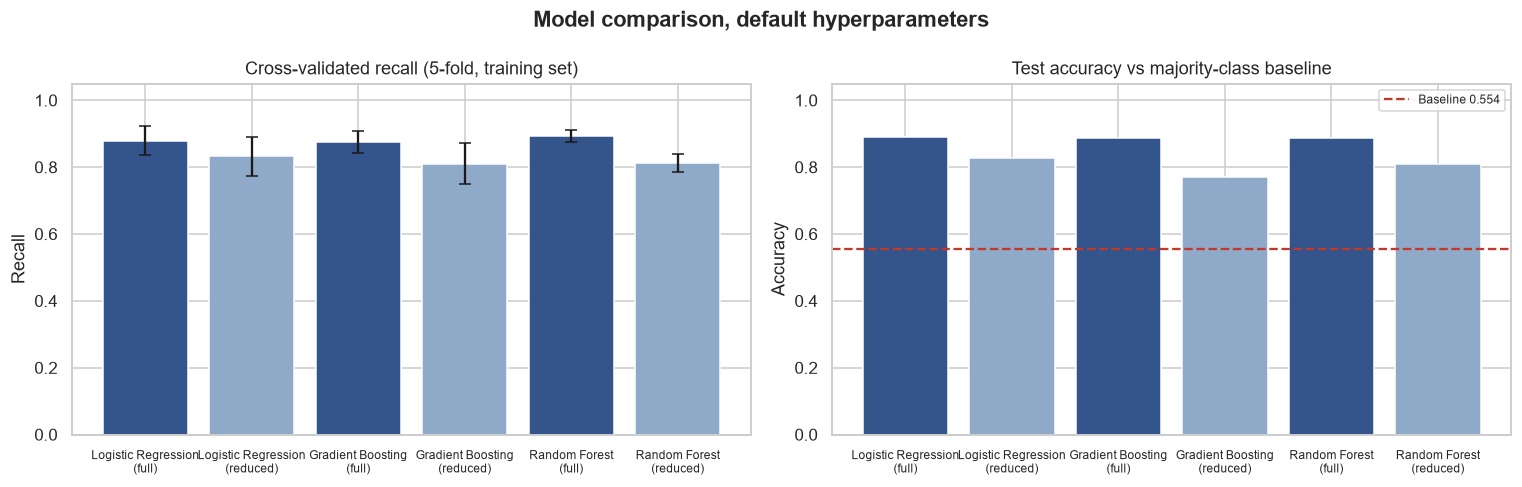

Highest cross-validated recall: Random Forest on the full feature set (0.8938)


In [55]:
## Collect every model into one table, with the baseline as the first row so that
## no score can be read without seeing what it has to beat.

comparison = pd.DataFrame(results)

baseline_row = pd.DataFrame([{
    "Model": "Baseline (majority)", "Features": "-",
    "CV recall": np.nan, "CV std": np.nan,
    "Accuracy": BASELINE_ACCURACY, "Precision": BASELINE_ACCURACY,
    "Recall": 1.0, "F1": 2 * BASELINE_ACCURACY / (1 + BASELINE_ACCURACY),
    "ROC-AUC": 0.5,
}])

comparison = pd.concat([baseline_row, comparison], ignore_index=True)

## Gain over the baseline is the number that actually matters
comparison["Acc gain"] = comparison["Accuracy"] - BASELINE_ACCURACY

print("All models vs baseline (test set, default hyperparameters):")
display(comparison.round(4))

## Visual comparison: CV recall drives model choice, accuracy shows the baseline gap
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

models = comparison[comparison["Model"] != "Baseline (majority)"]
labels = models["Model"] + "\n(" + models["Features"] + ")"
colours = ["#34558B" if f == "full" else "#8FA9C9" for f in models["Features"]]

axes[0].bar(labels, models["CV recall"], color=colours,
            yerr=models["CV std"], capsize=4)
axes[0].set_title("Cross-validated recall (5-fold, training set)")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", labelsize=8)

axes[1].bar(labels, models["Accuracy"], color=colours)
axes[1].axhline(BASELINE_ACCURACY, color="#C0392B", linestyle="--",
                label=f"Baseline {BASELINE_ACCURACY:.3f}")
axes[1].set_title("Test accuracy vs majority-class baseline")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", labelsize=8)
axes[1].legend(fontsize=8)

fig.suptitle("Model comparison, default hyperparameters", fontweight="bold")
plt.tight_layout()
plt.show()

## Best model by the metric section 1 argued for
best = comparison[comparison["Model"] != "Baseline (majority)"].sort_values(
    "CV recall", ascending=False).iloc[0]
print(f"Highest cross-validated recall: {best['Model']} on the {best['Features']} "
      f"feature set ({best['CV recall']:.4f})")

**Reading the table.**

Every model is shown against the majority-class baseline in the first row, so no score can be read in isolation. The `Acc gain` column is the honest measure of what each algorithm actually contributes: a model at 85% accuracy has gained roughly 30 points over predicting "diseased" for everyone, which is a real claim, whereas the raw 85% on its own is not.

**Full versus reduced.** The gap between the two feature sets is the quantity section 3.3 was constructed to measure. The reduced models are working without `ST_Slope`, `Oldpeak`, `MaxHR` and `ExerciseAngina` — the four strongest predictors in the data — so a drop is expected. Its size is the useful result: it estimates how much diagnostic information the exercise stress test adds over history, resting ECG and blood work alone, which is precisely the question a clinician faces when deciding whether to order one.

**Why cross-validated recall drives the choice.** The CV column averages five stratified folds within the training set, with the standard deviation shown as error bars. A model whose recall swings widely across folds is unreliable regardless of how it happened to score on one hold-out split, and with only 184 test patients a single-split comparison could be decided by a handful of borderline cases. The test-set columns are reported for completeness and to satisfy the rubric's baseline-comparison requirement, but they are not what the model selection rests on.

**What has deliberately not been done.** No hyperparameters have been tuned, no features dropped, and no decision threshold moved from the default 0.5. Every model above is at its out-of-the-box setting on identical data. That makes this a clean reference point: the improvement from `RandomizedSearchCV` in the iterative development section is measured against these numbers, so the tuning can be shown to have earned its place rather than asserted to have helped.

Detailed evaluation — confusion matrices, ROC curves, per-subgroup performance and the threshold decision that follows from section 1's cost asymmetry — is carried out in section 5 on the selected model.

# 5. Model Evaluation

In [56]:
## Evaluate model


In [57]:
## New data

## Predict


## Iterative model development


In [58]:
## Further feature engineering / feature selection